In [ ]:
!pip install transformers torch

In [ ]:
from transformers import pipeline

sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

hasil = sentiment_analyzer("Produknya bagus sekali, sangat memuaskan!")
print(hasil)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[{'label': 'positive', 'score': 0.9942994117736816}]


**DestilBERT**

In [ ]:
import pandas as pd

df = pd.read_csv('data_labeled.csv')   # dari Tugas 2
sample = df.head(10).copy()

hasil = sentiment_analyzer(sample['content_clean'].astype(str).tolist())
sample['prediksi_bert'] = [h['label'] for h in hasil]
sample['confidence']    = [round(h['score'], 3) for h in hasil]

print(sample[['content_clean', 'sentimen_auto', 'prediksi_bert', 'confidence']])

                                       content_clean sentimen_auto  \
0  aplikasi cukup membantu untuk cek rute dan pos...       positif   
1  biasa naik jak dan selalu muncul datanya di ap...       negatif   
2  jujur ini ngebantu banget sih buat pejuang tra...       positif   
3  aplikasi transjakarta ini jujur ngebantu bange...       positif   
4  transjakarta adalah alat yang sangat berguna d...       positif   
5  biasa naik jak dan jak dan selalu muncul datan...       negatif   
6  bintang buat kemudahannya skema rutenya jelas ...       positif   
7  membantu bgt utk tracking posisi bis jadi bisa...       positif   
8  aplikasinya sangat membantu untuk cek rute dan...       positif   
9  ini aplikasi bener ngebantu aku sebagai pendat...       positif   

  prediksi_bert  confidence  
0      positive       0.993  
1      negative       0.994  
2      positive       0.998  
3      positive       0.998  
4      positive       0.981  
5      negative       0.994  
6      positive    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df['content_clean'].astype(str)
y = df['sentimen_auto']
_, X_test_raw, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

hasil_bert = sentiment_analyzer(X_test_raw.tolist())
pred_bert  = [h['label'] for h in hasil_bert]

mapping = {'positive': 'positif', 'negative': 'negatif', 'neutral': 'netral'}
pred_bert_map = [mapping.get(p.lower(), p) for p in pred_bert]

print('=== DistilBERT / RoBERTa Indonesia ===')
print(f'Akurasi: {accuracy_score(y_test, pred_bert_map):.4f}')
print('\n', classification_report(y_test, pred_bert_map))

=== DistilBERT / RoBERTa Indonesia ===
Akurasi: 0.7597

               precision    recall  f1-score   support

     negatif       0.40      0.77      0.53        95
      netral       0.41      0.22      0.28       134
     positif       0.90      0.87      0.89       645

    accuracy                           0.76       874
   macro avg       0.57      0.62      0.57       874
weighted avg       0.77      0.76      0.76       874



**Data Test**

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sistem: Menjalankan testing menggunakan perangkat -> cpu


...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Sistem: Memulai proses prediksi pada data test...
Sistem: Proses testing selesai!
----------------------------------------
Akurasi Akhir DistilBERT pada Data Test: 0.11
----------------------------------------
Classification Report (DistilBERT):
              precision    recall  f1-score   support

     negatif       0.11      1.00      0.20        95
      netral       0.00      0.00      0.00       134
     positif       0.00      0.00      0.00       645

    accuracy                           0.11       874
   macro avg       0.04      0.33      0.07       874
weighted avg       0.01      0.11      0.02       874

----------------------------------------
Visualisasi Confusion Matrix (DistilBERT):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


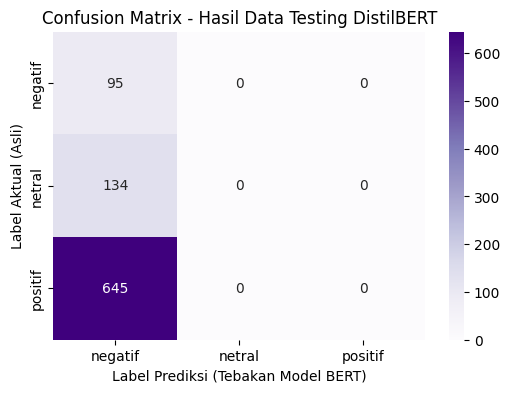

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. GUNAKAN DATAFRAME YANG SUDAH AKTIF DI MEMORI (SOLUSI ERROR)
# =========================================================================
# Load the DataFrame first
df = pd.read_csv('data_labeled.csv') # Added this line to define 'df'

# Kita langsung bersihkan baris kosong dari DataFrame 'df' yang ada di session Anda
df_aktif = df.dropna(subset=['content_clean', 'sentimen_auto']).copy()

X = df_aktif['content_clean'].astype(str).tolist()
y = df_aktif['sentimen_auto'].tolist()

# DistilBERT membutuhkan label berupa angka (0, 1, dst), bukan teks string
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# =========================================================================
# 2. TOKENIZATION KHAS DISTILBERT
# =========================================================================
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenisasi data test (X_test)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128, return_tensors="pt")

# Masukkan ke dalam PyTorch DataLoader
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], torch.tensor(y_test))
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# =========================================================================
# 3. LOAD PRETRAINED MODEL DISTILBERT
# =========================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sistem: Menjalankan testing menggunakan perangkat -> {device}")

num_labels = len(label_encoder.classes_)
model_distilbert = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=num_labels)
model_distilbert.to(device)

# =========================================================================
# 4. PROSES TESTING (INFERENCE)
# =========================================================================
model_distilbert.eval()
y_pred_bert = []

print("Sistem: Memulai proses prediksi pada data test...")
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, _ = [b.to(device) for b in batch]
        outputs = model_distilbert(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        y_pred_bert.extend(preds)

print("Sistem: Proses testing selesai!\n" + "-"*40)

# =========================================================================
# 5. EVALUASI DAN VISUALISASI
# =========================================================================
target_names = label_encoder.classes_

# Menampilkan Skor Akurasi
akurasi_bert = accuracy_score(y_test, y_pred_bert)
print(f"Akurasi Akhir DistilBERT pada Data Test: {akurasi_bert:.2f}")
print('-' * 40)

# Menampilkan Classification Report
print("Classification Report (DistilBERT):")
print(classification_report(y_test, y_pred_bert, target_names=target_names))
print('-' * 40)

# Menampilkan Visualisasi Confusion Matrix
print("Visualisasi Confusion Matrix (DistilBERT):")
cm_bert = confusion_matrix(y_test, y_pred_bert)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix - Hasil Data Testing DistilBERT')
plt.ylabel('Label Aktual (Asli)')
plt.xlabel('Label Prediksi (Tebakan Model BERT)')
plt.show()